In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from boulder_statistics.analysis.quick_calculate import FittingFunction
from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
def get_fit_summary_to_export(model):
    results = {}

    results["params"] = model.params
    results["BIC"] = model.bic
    results["AIC"] = model.aic
    results["pvalues"] = model.pvalues

    try:
        results["cov_params"] = model.cov_params()
    except ValueError:
        results["cov_params"] = np.nan

    return results

In [3]:
runs_data = [np.load(file) for file in Path("results_jacobian").iterdir() if ".npz" in file.suffix]

runs_data_dfs = [
    pl.DataFrame({
        # "e" : np.float32(run_data["params"][0]),
        "g" : np.float32(run_data["params"][0]),
        "d" : np.float32(run_data["params"][1]),
        "min_LAD" : np.float32(run_data["min_LAD"]),
        "AIC" : np.float32(run_data["AIC"]),
        "g_err" : np.float32(np.sqrt(np.diag(run_data["cov_params"]))[0]) if run_data["cov_params"].size != 1 else np.float32(0),
        "d_err" : np.float32(np.sqrt(np.diag(run_data["cov_params"]))[1]) if run_data["cov_params"].size != 1 else np.float32(0),
        "mean_log_like_obs" : np.float32(run_data["mean_log_like_obs"]),
        "number_of_samples" : np.int32(run_data["number_of_samples"])
    })
    for run_data in runs_data
    # if run_data["cov_params"] is not np.nan
]

In [4]:
normalize = lambda x : (x - x.mean()) / (x.max() - x.min())
normalize_err = lambda x, x_err : x_err / (x.max() - x.min())

runs_data_df = pl.concat(runs_data_dfs).filter(pl.col("d") < 0, pl.col("min_LAD") > 0.3)

runs_data_df

g,d,min_LAD,AIC,g_err,d_err,mean_log_like_obs,number_of_samples
f32,f32,f32,f32,f32,f32,f32,i32
2.344124,-1.903065,0.304315,4.529048e6,0.000043,0.003936,-6.324821,358037
2.313112,-1.916682,0.312076,4.475345e6,0.000041,0.003989,-6.339795,352956
2.327771,-1.928808,0.313898,4462330.5,0.000034,0.004018,-6.343554,351721
2.31659,-1.936502,0.317529,4.436391e6,0.000044,0.004047,-6.350718,349282
2.065224,-1.950374,0.360479,4.1284e6,0.000034,0.00426,-6.436925,320682
…,…,…,…,…,…,…,…
1.00634,-3.038583,5.613465,42043.261719,0.000097,0.084493,-10.440949,2013
0.977773,-3.054421,7.008245,22460.697266,0.000158,0.099786,-10.825794,1037
1.006157,-3.048306,7.169465,21288.419922,0.00016,0.115607,-10.857357,980


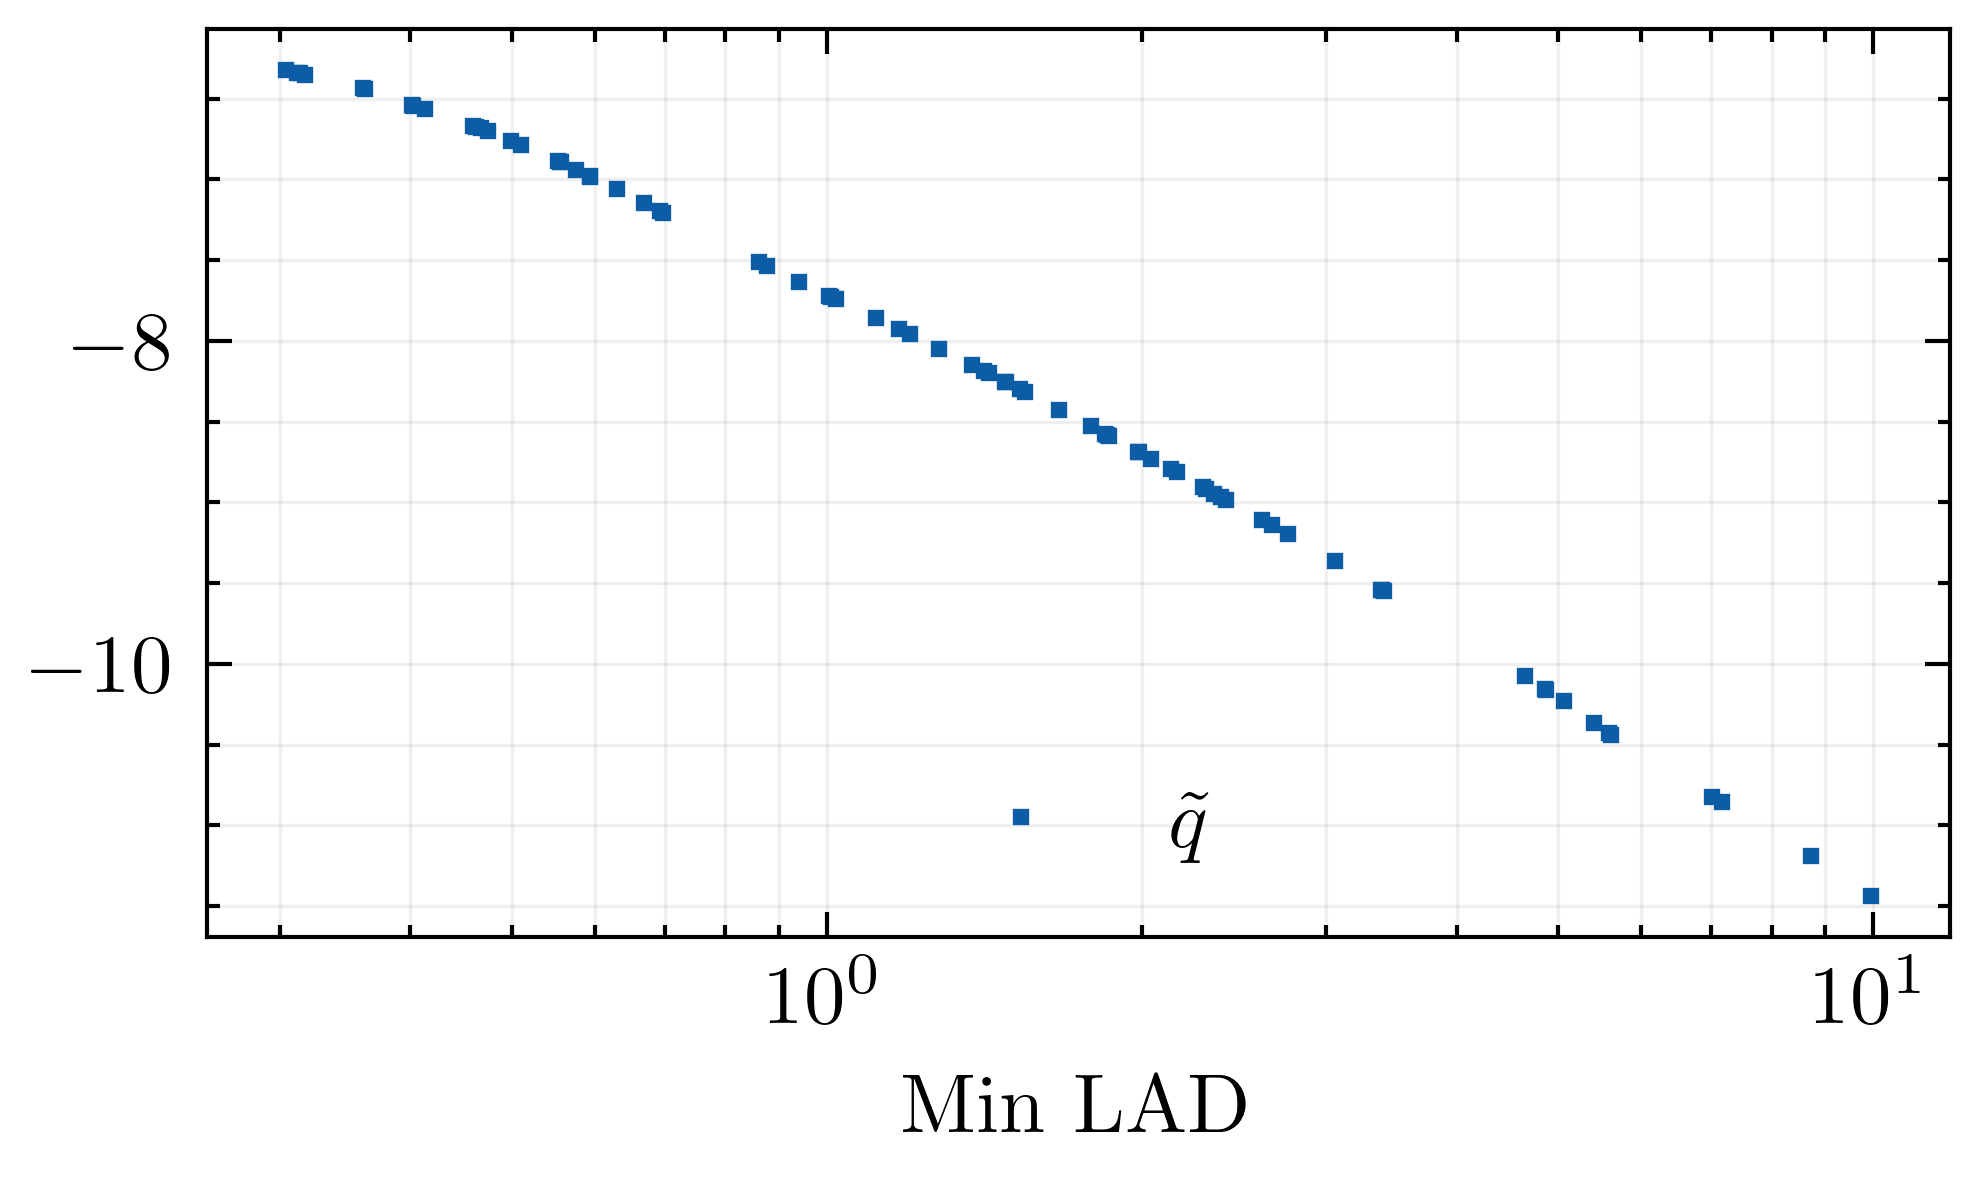

In [5]:
plt.errorbar(runs_data_df["min_LAD"], runs_data_df["mean_log_like_obs"], label = r"$\tilde{q}$", capsize=1, fmt = "s", markersize=1)

plt.xlabel("Min LAD")
plt.xscale("log")
# plt.xlim(runs_data_df["min_LAD"].min(), 4)
plt.legend(ncol=3, loc='lower center')
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig("many_fits.png")
plt.show()

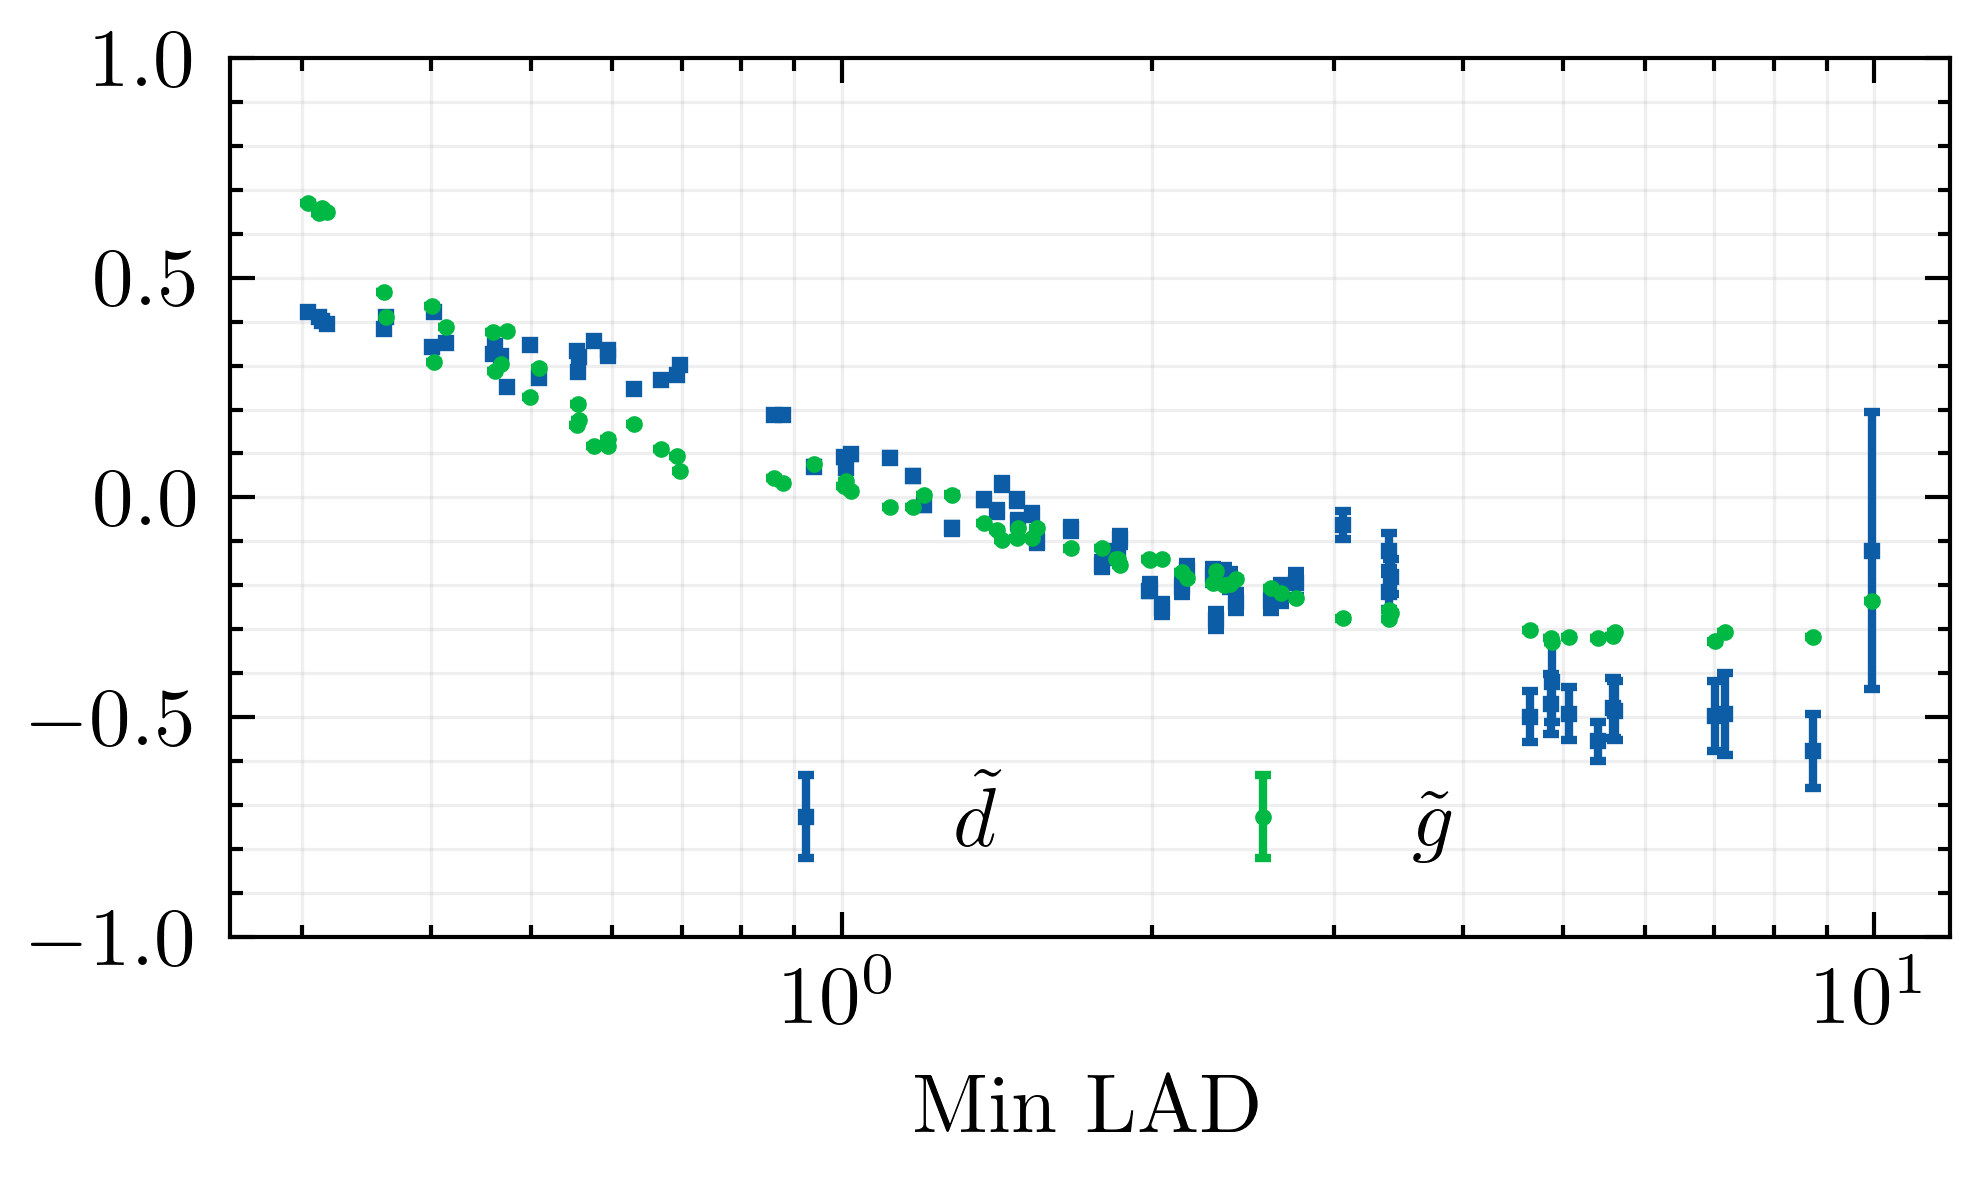

In [6]:
plt.errorbar(runs_data_df["min_LAD"], normalize(runs_data_df["d"]), normalize_err(runs_data_df["d"], runs_data_df["d_err"]), label = r"$\tilde{d}$", capsize=1, fmt = "s", markersize=1)
plt.errorbar(runs_data_df["min_LAD"], normalize(runs_data_df["g"]), normalize_err(runs_data_df["g"], runs_data_df["g_err"]), label = r"$\tilde{g}$", capsize=1, fmt = "o", markersize=1)

plt.xlabel("Min LAD")
plt.xscale("log")
# plt.xlim(runs_data_df["min_LAD"].min(), 4)
plt.ylim(-1, 1)
plt.legend(ncol=3, loc='lower center')
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig("many_fits.png")
plt.show()

In [7]:
from scipy.optimize import curve_fit

def power_law(x, a, p):
    return a * (x**p)

runs_data_df_valid = runs_data_df.filter(pl.col("min_LAD") < 3, pl.col("min_LAD") > 0.5)

xs = runs_data_df_valid["min_LAD"].to_numpy()
ys = runs_data_df_valid["g"].to_numpy()

params, covariance = curve_fit(
    power_law, xs, ys, p0=[1.0, -1])

a_fit, p_fit = params

print(f"a = {a_fit}")
print(f"p = {p_fit}")

# Standard errors
errors = np.sqrt(np.diag(covariance))
print(f"std_a = {errors[0]}, std_p = {errors[1]}")

a = 1.4474675622551785
p = -0.24575407108619918
std_a = 0.005545988557465627, std_p = 0.007116845324036178


C:\Users\Joshu\AppData\Local\Temp\ipykernel_16932\2617353502.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 4)


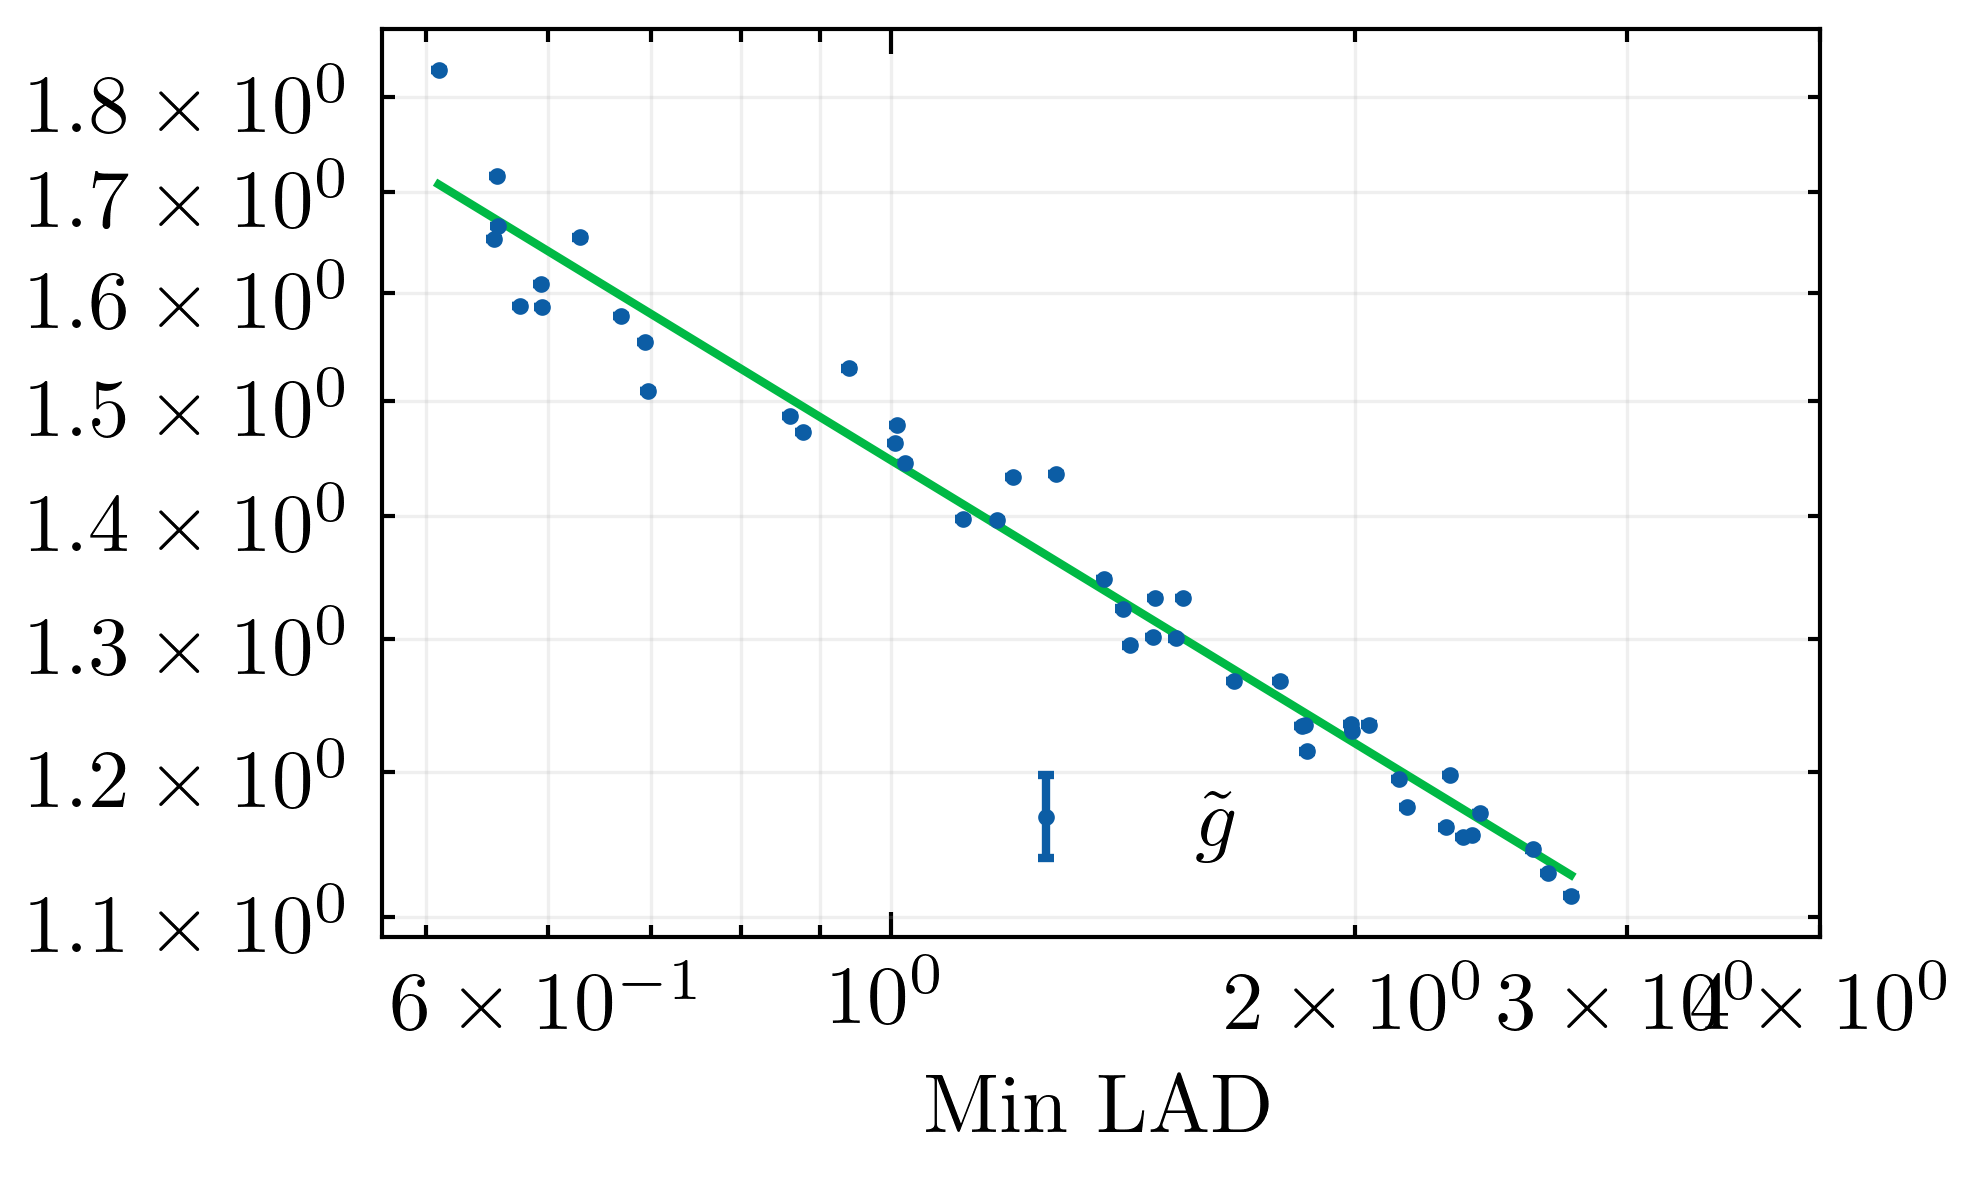

1.0198885202407837


In [8]:
plt.errorbar(runs_data_df_valid["min_LAD"], runs_data_df_valid["g"], runs_data_df_valid["g_err"],
             label = r"$\tilde{g}$", capsize=1, fmt = "o", markersize=1)

plt.plot(runs_data_df_valid["min_LAD"].to_numpy(), power_law(runs_data_df_valid["min_LAD"].to_numpy(), *params))

plt.xlabel("Min LAD")
plt.yscale("log")
plt.xscale("log")
# plt.yscale("log")
plt.xlim(0, 4)
plt.legend(ncol=3, loc='lower center')
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig("many_fits.png")
plt.show()

mean_g_stable = runs_data_df.filter(pl.col("min_LAD") > 7)["g"].mean()
print(mean_g_stable)



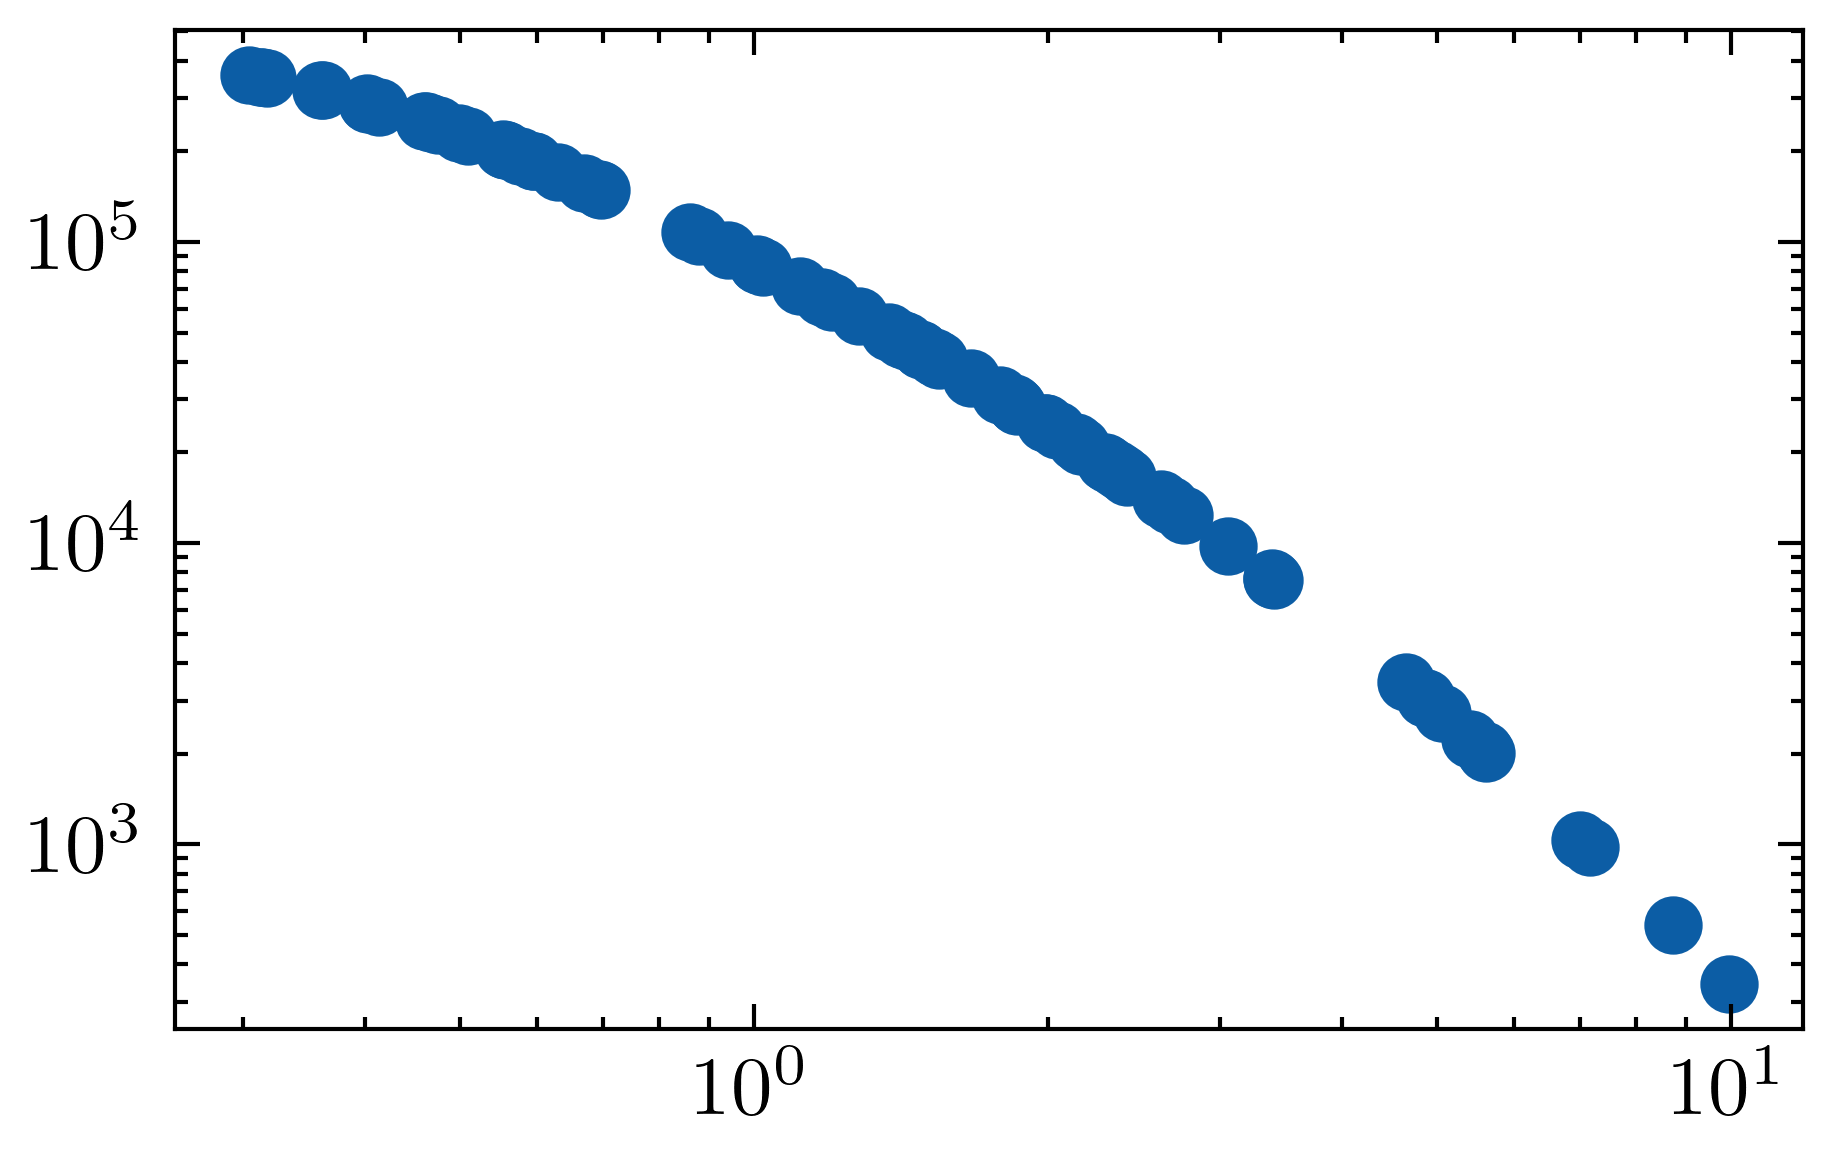

In [9]:
plt.scatter(runs_data_df["min_LAD"], runs_data_df["number_of_samples"])
plt.xscale("log")
plt.yscale("log")

In [10]:
from sklearn.metrics import r2_score

xs = runs_data_df_valid["min_LAD"].to_numpy()
ys = runs_data_df_valid["d"].to_numpy()
y_errs = runs_data_df_valid["d_err"].to_numpy()

def fit_func(x, a, p):
    return a + p * np.log(x)

params, covariance = curve_fit(
    fit_func, xs, ys, p0=[-2.3, -0.4])

a_fit, p_fit = params

print(f"a = {a_fit}")
print(f"p = {p_fit}")

# Standard errors
errors = np.sqrt(np.diag(covariance))
print(f"std_a = {errors[0]}, std_p = {errors[1]}")
r2 = r2_score(ys, fit_func(xs, *params))
print(f"r2 = {r2}")

a = -2.3017972491295846
p = -0.4681253383066037
std_a = 0.00859580892957138, std_p = 0.01501267485507416
r2 = 0.9567064475233432


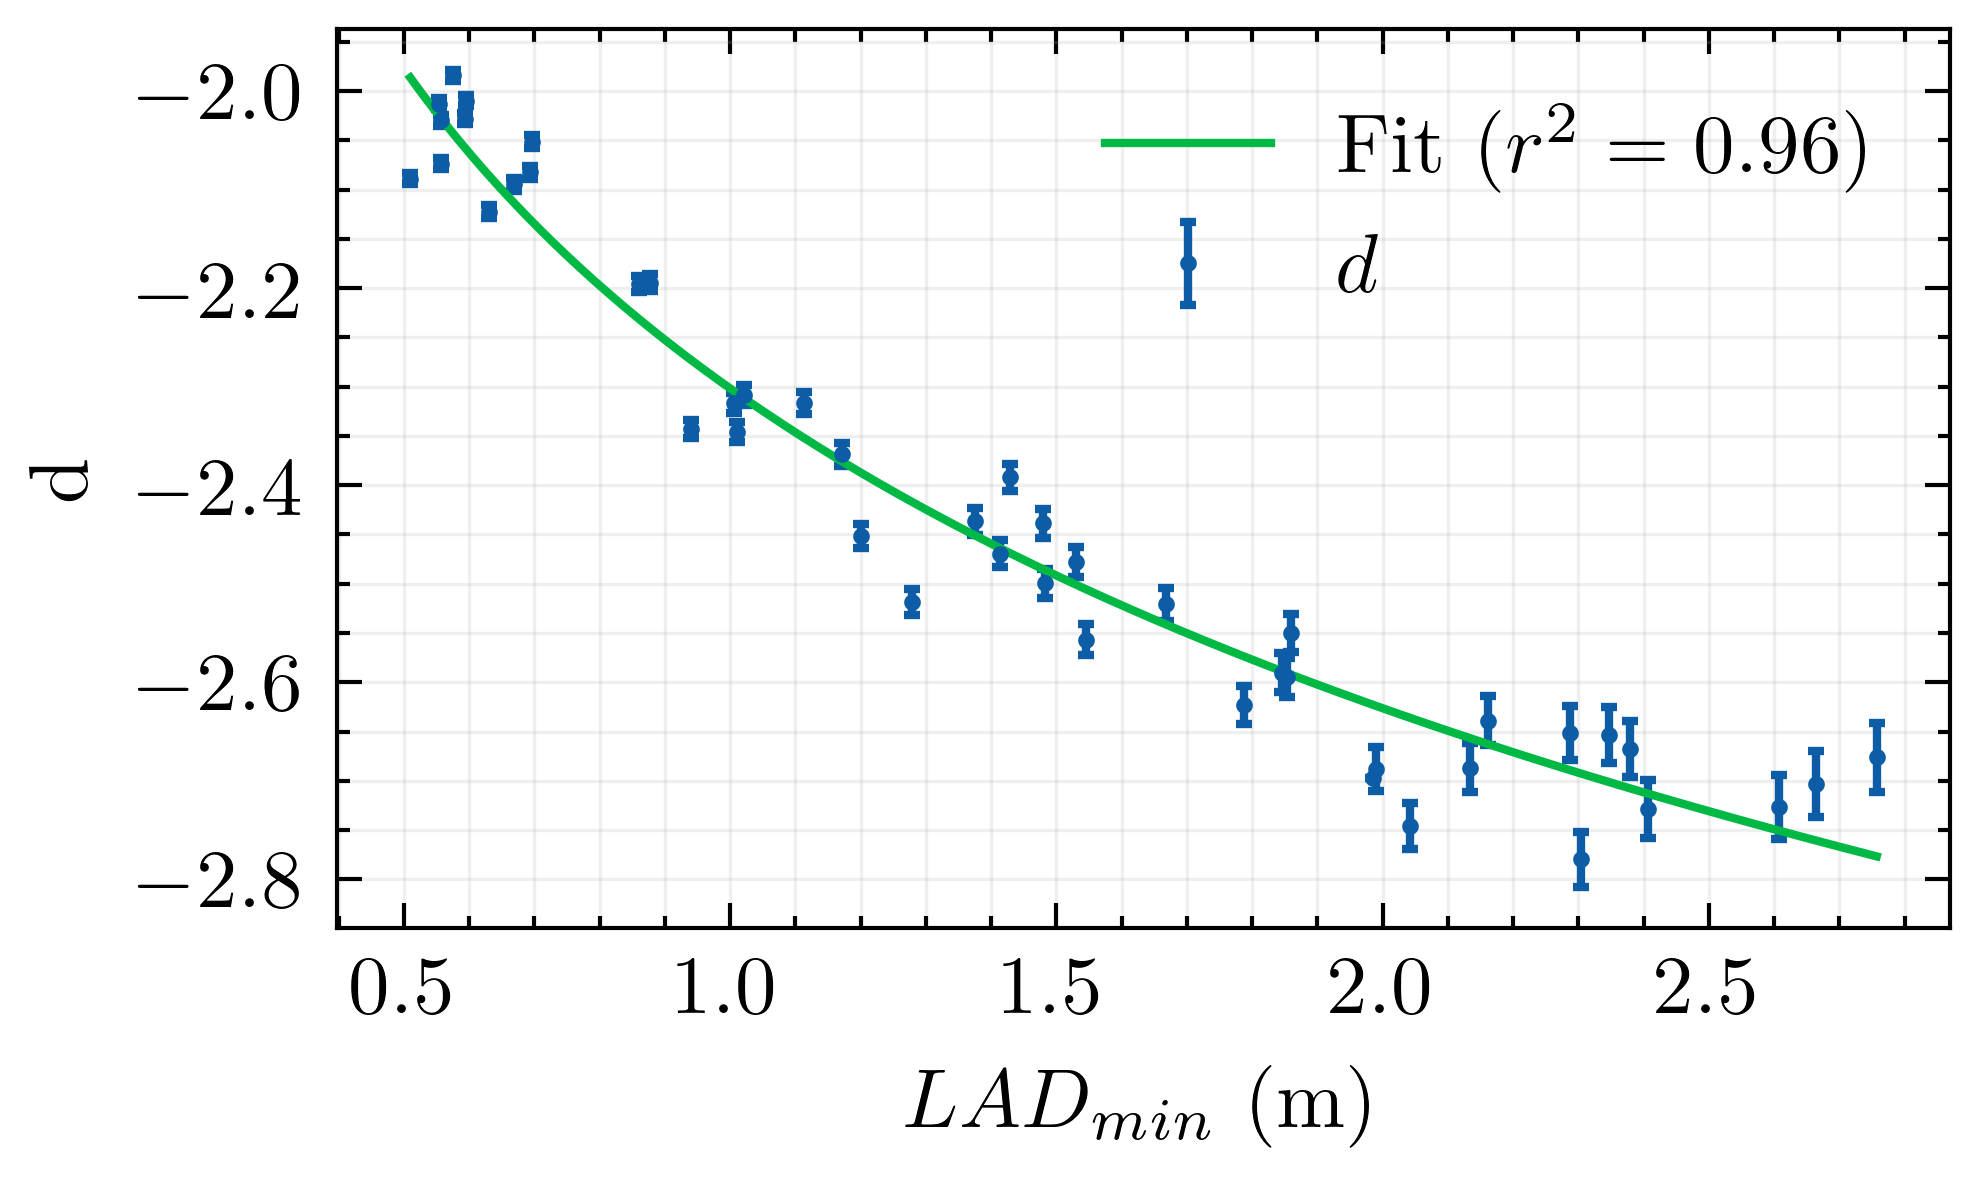

Fit params = d_a = -2.30 pm 0.01, d_b = -0.47 pm 0.02


In [11]:
plot_xs = np.linspace(xs.min(), xs.max(), 1000)

plt.errorbar(runs_data_df_valid["min_LAD"], runs_data_df_valid["d"], runs_data_df_valid["d_err"], label = r"$d$", capsize=1, fmt = "o", markersize=1)
plt.plot(plot_xs, fit_func(plot_xs, *params), label = rf"Fit ($r^2 = {r2:.2f}$)")

plt.xlabel("$LAD_{min}$ (m)")
plt.ylabel("d")
# plt.xscale("log")
# plt.xlim(1e4, 3e5)
# plt.xlim(0.5, 3)
# plt.xlim(runs_data_df["min_LAD"].min(), 4)
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig("d_vs_Min_LAD.png")
plt.show()

print(f"Fit params = d_a = {params[0]:.2f} pm {errors[0]:.2f}, d_b = {params[1]:.2f} pm {errors[1]:.2f}")

In [12]:
# g = 0.4285
# e = 0.4727540910243988